<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")


All libraries installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [ ]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                      ║
# ╚═════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers as KL, Input as KInput, Model as KModel

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 3: SETUP — restores state from Notebook 2              ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_2_to_3"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 2 state loaded successfully.")

CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_2_to_3.pkl
  Variables restored    : 336
  Keras models restored : ['mlp_base_model']
  df_combined shape      : (299999, 51)

Notebook 2 state loaded successfully.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — OPTUNA: FINE-TUNE MLP (RESIDUAL ARCHITECTURE)         ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
MLP Optuna fine-tuning — improved architecture vs baseline.

Architecture improvements vs baseline 2-layer flat network:
  RESIDUAL BLOCKS: Dense → BN → ReLU → Dense + skip connection.
    Prevents vanishing gradients and allows deeper networks.
  HUBER LOSS: Quadratic for small errors, linear for large errors.
    Prevents high-price outliers from dominating the gradient.
  TARGET NORMALISATION: log_price standardised before MLP training.
    Trees handle unnormalised targets fine; MLPs benefit strongly.
  COSINE LR DECAY: lr starts at lr_max, decays to lr_min=1e-6.
    Prevents oscillation near convergence.
  GRADIENT CLIPPING (clipnorm=1.0): prevents exploding gradients.
  ReduceLROnPlateau: halves lr if val_loss stalls for 5 epochs.

Search space (30 trials):
  u1 (first block units) : {128, 256, 512}
  u2 (second block units): {64, 128, 256}
  dropout_rate           : 0.1 – 0.4
  learning_rate          : 5e-4 – 3e-3  (tighter than baseline)
  batch_size             : {256, 512, 1024}
  l2_reg                 : 1e-5 – 1e-3
  huber_delta            : 0.5 – 2.0
"""

print("=" * 65)
print("CELL 22 — OPTUNA: MLP RESIDUAL ARCHITECTURE (30 trials)")
print("=" * 65)

def build_residual_mlp(u1, u2, dr, l2, n_input):
    """
    Dual residual block MLP.
    Block 1: Dense(u1) → BN → ReLU → Dropout → Dense(u1) + skip
    Block 2: Dense(u2) → BN → ReLU → Dropout + projected skip
    Output: Dense(1) linear
    """
    reg = keras.regularizers.l2(l2)
    inp = KInput(shape=(n_input,))

    # Block 1 (same-dimension residual)
    x  = KL.Dense(u1, kernel_regularizer=reg)(inp)
    x  = KL.BatchNormalization()(x)
    x  = KL.Activation("relu")(x)
    x  = KL.Dropout(dr)(x)
    x2 = KL.Dense(u1, kernel_regularizer=reg)(x)
    x2 = KL.BatchNormalization()(x2)
    x2 = KL.Activation("relu")(x2)
    x2 = KL.Dropout(dr * 0.7)(x2)
    x  = KL.Add()([x, x2])

    # Block 2 (projected residual: u1 → u2)
    x3 = KL.Dense(u2, kernel_regularizer=reg)(x)
    x3 = KL.BatchNormalization()(x3)
    x3 = KL.Activation("relu")(x3)
    x3 = KL.Dropout(dr * 0.5)(x3)
    xp = KL.Dense(u2, use_bias=False)(x)   # projection
    x  = KL.Add()([x3, xp])

    out   = KL.Dense(1)(x)
    model = KModel(inputs=inp, outputs=out)
    return model

def cosine_lr(epoch, total, lr_max, lr_min=1e-6):
    """Cosine decay from lr_max to lr_min over total epochs."""
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / total))

N_MLP_EPOCHS = 120

def mlp_objective(trial):
    """Maximise validation R² with improved MLP architecture."""
    u1    = trial.suggest_categorical("u1",  [128, 256, 512])
    u2    = trial.suggest_categorical("u2",  [64,  128, 256])
    dr    = trial.suggest_float("dr",         0.1,  0.4)
    lr    = trial.suggest_float("lr",         5e-4, 3e-3, log=True)
    bs    = trial.suggest_categorical("bs",  [256,  512, 1024])
    l2    = trial.suggest_float("l2",         1e-5, 1e-3, log=True)
    delta = trial.suggest_float("delta",      0.5,  2.0)

    m = build_residual_mlp(u1, u2, dr, l2, n_feat)
    m.compile(optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
               loss=keras.losses.Huber(delta=delta))
    lr_cb = keras.callbacks.LearningRateScheduler(
        lambda ep: cosine_lr(ep, N_MLP_EPOCHS, lr_max=lr))
    m.fit(Xtr_sc, yr_tr_sc,
          validation_data=(Xva_sc, yr_va_sc),
          epochs=N_MLP_EPOCHS, batch_size=bs, verbose=0,
          callbacks=[
              keras.callbacks.EarlyStopping(
                  patience=15, min_delta=1e-4,
                  restore_best_weights=True),
              keras.callbacks.ReduceLROnPlateau(
                  monitor="val_loss", factor=0.5, patience=5,
                  min_lr=1e-6, verbose=0),
              lr_cb,
          ])
    preds = denorm_y(m.predict(Xva_sc, verbose=0).flatten())
    return r2_score(y_reg_val.values, preds)

mlp_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED))
mlp_study.optimize(mlp_objective, n_trials=30, show_progress_bar=True)
bp_mlp = mlp_study.best_params
print(f"\nBest MLP params : {bp_mlp}")

# Train final MLP with best params
N_FINAL = 200
mlp_tuned = build_residual_mlp(
    bp_mlp["u1"], bp_mlp["u2"], bp_mlp["dr"], bp_mlp["l2"], n_feat)
mlp_tuned.compile(
    optimizer=keras.optimizers.Adam(bp_mlp["lr"], clipnorm=1.0),
    loss=keras.losses.Huber(delta=bp_mlp["delta"]))
lr_final_cb = keras.callbacks.LearningRateScheduler(
    lambda ep: cosine_lr(ep, N_FINAL, lr_max=bp_mlp["lr"]))
mlp_tuned.fit(Xtr_sc, yr_tr_sc,
               validation_data=(Xva_sc, yr_va_sc),
               epochs=N_FINAL, batch_size=bp_mlp["bs"], verbose=0,
               callbacks=[
                   keras.callbacks.EarlyStopping(
                       patience=20, min_delta=1e-4,
                       restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(
                       monitor="val_loss", factor=0.5, patience=5,
                       min_lr=1e-6, verbose=0),
                   lr_final_cb,
               ])

mlp_tuned_preds = denorm_y(mlp_tuned.predict(Xva_sc, verbose=0).flatten())
mlp_bl_r2  = results_baseline[2]["R2"]
res_mlp_t  = evaluate_reg(y_reg_val, mlp_tuned_preds, "MLP (residual, tuned)", "val")
results_tuned.append(res_mlp_t)
print(f"\nMLP improvement: {mlp_bl_r2:.4f} → {res_mlp_t['R2']:.4f}  "
      f"({res_mlp_t['R2'] - mlp_bl_r2:+.4f})")

CELL 22 — OPTUNA: MLP RESIDUAL ARCHITECTURE (30 trials)


  0%|          | 0/30 [00:00<?, ?it/s]


Best MLP params : {'u1': 512, 'u2': 256, 'dr': 0.20658920487599386, 'lr': 0.0005967106747797542, 'bs': 512, 'l2': 1.4263660907094013e-05, 'delta': 1.451019488860582}
  MLP (residual, tuned)                      [val] R²=0.7696  RMSE=0.4742  MAE=0.1977  Real-MAE=$68,157

MLP improvement: 0.7422 → 0.7696  (+0.0274)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 23 — OPTUNA: FINE-TUNE HISTGRADIENTBOOSTING                ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
HistGradientBoosting Optuna fine-tuning.

Why HGB is valuable in this ensemble:
  • Handles NaN natively (no imputation needed) — important because
    zip_numeric is 30% NaN in this dataset.
  • Histogram binning is extremely fast on 300K rows (much faster than
    CatBoost at the same depth).
  • Provides a different inductive bias from CatBoost (no symmetric
    trees, no ordered boosting) — adds diversity to the ensemble.

Search space (20 trials):
  learning_rate      : 0.01 – 0.3  (log-uniform)
  max_iter           : 200 – 1000  (step 100)
  max_depth          : 3 – 10
  min_samples_leaf   : 10 – 100
  l2_regularization  : 0.0 – 10.0
  max_bins           : {63, 127, 255}
"""

print("=" * 65)
print("CELL 23 — OPTUNA: HISTGRADIENTBOOSTING (20 trials)")
print("=" * 65)

def hgb_objective(trial):
    """Maximise validation R². HGB uses raw arrays."""
    params = {
        "learning_rate":     trial.suggest_float("lr",          0.01, 0.3, log=True),
        "max_iter":          trial.suggest_int("max_iter",      200,  1000, step=100),
        "max_depth":         trial.suggest_int("depth",         3,    10),
        "min_samples_leaf":  trial.suggest_int("min_leaf",      10,   100),
        "l2_regularization": trial.suggest_float("l2",          0.0,  10.0),
        "max_bins":          trial.suggest_categorical("bins",   [63, 127, 255]),
        "early_stopping":    True,
        "validation_fraction": 0.1,
        "n_iter_no_change":  15,
        "random_state": SEED,
    }
    m = HistGradientBoostingRegressor(**params)
    m.fit(Xtr_raw, y_reg_train)
    return r2_score(y_reg_val, m.predict(Xva_raw))

hgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED))
hgb_study.optimize(hgb_objective, n_trials=20, show_progress_bar=True)
hgb_bp = hgb_study.best_params
print(f"\nBest HGB params : {hgb_bp}")

hgb_tuned = HistGradientBoostingRegressor(
    learning_rate    = hgb_bp["lr"],
    max_iter         = hgb_bp["max_iter"],
    max_depth        = hgb_bp["depth"],
    min_samples_leaf = hgb_bp["min_leaf"],
    l2_regularization= hgb_bp["l2"],
    max_bins         = hgb_bp["bins"],
    early_stopping   = True,
    validation_fraction=0.1,
    n_iter_no_change = 15,
    random_state=SEED)
hgb_tuned.fit(Xtr_raw, y_reg_train)

hgb_bl_r2  = results_baseline[3]["R2"]
res_hgb_t  = evaluate_reg(y_reg_val, hgb_tuned.predict(Xva_raw), "HGB (tuned)", "val")
results_tuned.append(res_hgb_t)
print(f"\nHGB improvement: {hgb_bl_r2:.4f} → {res_hgb_t['R2']:.4f}  "
      f"({res_hgb_t['R2'] - hgb_bl_r2:+.4f})")


CELL 23 — OPTUNA: HISTGRADIENTBOOSTING (20 trials)


  0%|          | 0/20 [00:00<?, ?it/s]


Best HGB params : {'lr': 0.14951203959567103, 'max_iter': 500, 'depth': 9, 'min_leaf': 25, 'l2': 2.289048785050259, 'bins': 255}
  HGB (tuned)                                [val] R²=0.7884  RMSE=0.4544  MAE=0.1793  Real-MAE=$61,335

HGB improvement: 0.7745 → 0.7884  (+0.0139)


CELL 25 — BASELINE vs TUNED COMPARISON (Validation Set)
        Model  Baseline R²  Tuned R²    ΔR²  Baseline RMSE  Tuned RMSE  ΔRMSE Tuned RealMAE
Random Forest       0.7947    0.7993 0.0046         0.4476      0.4426 0.0051       $53,097
     CatBoost       0.7684    0.7873 0.0189         0.4754      0.4556 0.0198       $60,602
          MLP       0.7422    0.7696 0.0274         0.5015      0.4742 0.0274       $68,157
          HGB       0.7745    0.7884 0.0139         0.4691      0.4544 0.0147       $61,335


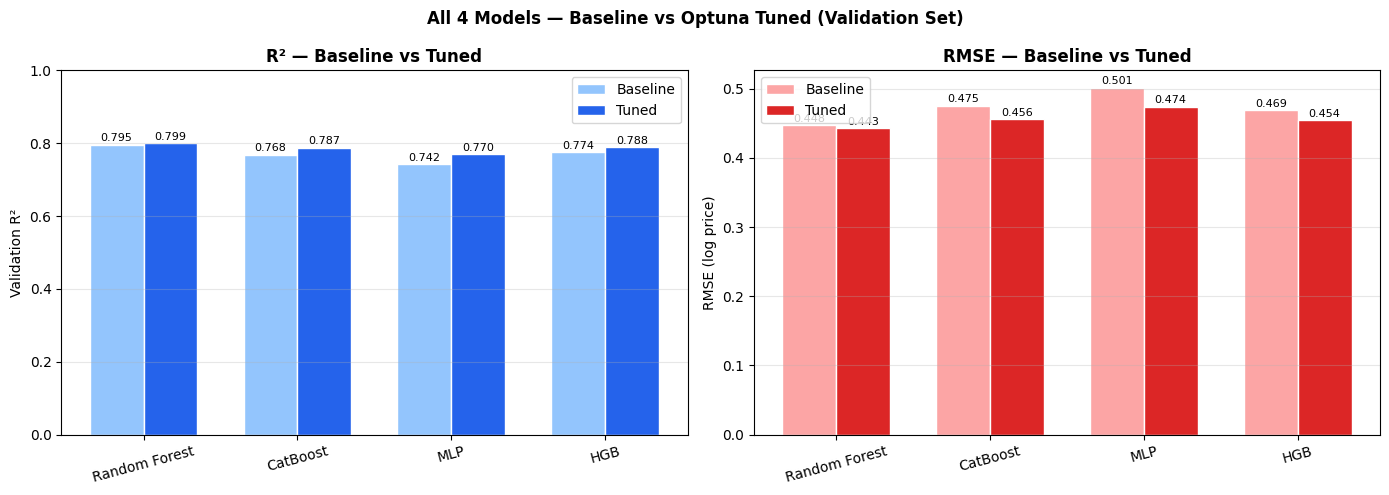

Chart saved → /content/drive/MyDrive/RealEstate_TXNY/comparison_baseline_tuned.png


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 25 — BEFORE vs AFTER TUNING COMPARISON TABLE               ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Side-by-side comparison of baseline vs tuned validation performance
for all 4 models. Shows R², RMSE, and real-dollar MAE.
"""

print("=" * 65)
print("CELL 25 — BASELINE vs TUNED COMPARISON (Validation Set)")
print("=" * 65)

comparison_rows = []
model_names = ["Random Forest","CatBoost","MLP","HGB"]
for i, (bl, tu) in enumerate(zip(results_baseline, results_tuned)):
    comparison_rows.append({
        "Model":          model_names[i],
        "Baseline R²":    round(bl["R2"],   4),
        "Tuned R²":       round(tu["R2"],   4),
        "ΔR²":            round(tu["R2"] - bl["R2"], 4),
        "Baseline RMSE":  round(bl["RMSE"], 4),
        "Tuned RMSE":     round(tu["RMSE"], 4),
        "ΔRMSE":          round(bl["RMSE"] - tu["RMSE"], 4),
        "Tuned RealMAE":  f"${tu['Real_MAE_USD']:,.0f}",
    })

comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

# Visual bar chart
fig_comp, axes_c = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(model_names))
width = 0.35

ax_r2 = axes_c[0]
bl_r2 = [r["Baseline R²"] for r in comparison_rows]
tu_r2 = [r["Tuned R²"]    for r in comparison_rows]
ax_r2.bar(x_pos - width/2, bl_r2, width, label="Baseline", color="#93C5FD", edgecolor="white")
ax_r2.bar(x_pos + width/2, tu_r2, width, label="Tuned",    color="#2563EB", edgecolor="white")
ax_r2.set_xticks(x_pos); ax_r2.set_xticklabels(model_names, rotation=15)
ax_r2.set_ylabel("Validation R²"); ax_r2.set_ylim(0, 1)
ax_r2.set_title("R² — Baseline vs Tuned", fontweight="bold")
ax_r2.legend(); ax_r2.grid(axis="y", alpha=0.3)
for i, (b, t) in enumerate(zip(bl_r2, tu_r2)):
    ax_r2.text(i - width/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=8)
    ax_r2.text(i + width/2, t + 0.01, f"{t:.3f}", ha="center", fontsize=8)

ax_rm = axes_c[1]
bl_rm = [r["Baseline RMSE"] for r in comparison_rows]
tu_rm = [r["Tuned RMSE"]    for r in comparison_rows]
ax_rm.bar(x_pos - width/2, bl_rm, width, label="Baseline", color="#FCA5A5", edgecolor="white")
ax_rm.bar(x_pos + width/2, tu_rm, width, label="Tuned",    color="#DC2626", edgecolor="white")
ax_rm.set_xticks(x_pos); ax_rm.set_xticklabels(model_names, rotation=15)
ax_rm.set_ylabel("RMSE (log price)"); ax_rm.set_title("RMSE — Baseline vs Tuned", fontweight="bold")
ax_rm.legend(); ax_rm.grid(axis="y", alpha=0.3)
for i, (b, t) in enumerate(zip(bl_rm, tu_rm)):
    ax_rm.text(i - width/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
    ax_rm.text(i + width/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=8)

plt.suptitle("All 4 Models — Baseline vs Optuna Tuned (Validation Set)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/comparison_baseline_tuned.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {SAVE_DIR}/comparison_baseline_tuned.png")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 26 — 5-FOLD OUT-OF-FOLD (OOF) PREDICTIONS                 ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Generate 5-fold OOF predictions for all 5 tuned models.

Why OOF and why it matters:
  OOF (out-of-fold) predictions are the foundation of Level 2 stacking.
  Each fold trains on 4/5 of the training data and predicts the held-out
  1/5. Concatenating these gives predictions for ALL training rows, but
  none of them saw their own prediction row during training.

  This is critical: if you simply train a model on the full training set
  and predict on it, the model has memorised its training data and the
  predictions are unrealistically good. Ridge meta-learner trained on
  such predictions would overfit. OOF predictions prevent this leak.

Structure of OOF arrays:
  oof_rf   : shape (n_train,) — RF predictions for every training row
  oof_cat  : shape (n_train,) — CatBoost predictions
  oof_mlp  : shape (n_train,) — MLP predictions
  oof_hgb  : shape (n_train,) — HGB predictions

These 5 arrays will be used as features for the Ridge meta-learner
in the next cell.

Additionally, each base model generates test-set predictions by
training on the FULL training set (standard stacking protocol).
"""

print("=" * 65)
print("CELL 26 — 5-FOLD OOF PREDICTIONS (ALL 4 TUNED MODELS)")
print("=" * 65)

kf      = KFold(n_splits=5, shuffle=True, random_state=SEED)
n_train = len(X_train)
oof_rf  = np.zeros(n_train)
oof_cat = np.zeros(n_train)
oof_mlp = np.zeros(n_train)
oof_hgb = np.zeros(n_train)


yr_train_vals = y_reg_train.values

for fold_idx, (tri, vli) in enumerate(kf.split(Xtr_rf)):
    print(f"\n  ── FOLD {fold_idx+1}/5 "
          f"(train={len(tri):,}  val={len(vli):,}) ──────────────────")

    # ── Fold data slices ────────────────────────────────────────────
    Xf_tr = Xtr_rf[tri];   Xf_va = Xtr_rf[vli]
    Xs_tr = Xtr_sc[tri];   Xs_va = Xtr_sc[vli]
    Xr_tr = Xtr_raw[tri];  Xr_va = Xtr_raw[vli]
    yf_tr = yr_train_vals[tri]
    yf_va = yr_train_vals[vli]
    ys_tr = norm_y(yf_tr); ys_va = norm_y(yf_va)

    # ── RF fold ─────────────────────────────────────────────────────
    rf_f = RandomForestRegressor(
        n_estimators    = rf_bp["n_est"],
        max_depth       = rf_bp["depth"],
        min_samples_leaf= rf_bp["min_leaf"],
        max_features    = rf_bp["max_f"],
        n_jobs=-1, random_state=SEED)
    rf_f.fit(Xf_tr, yf_tr)
    oof_rf[vli] = rf_f.predict(Xf_va)
    print(f"    RF       R²: {r2_score(yf_va, oof_rf[vli]):.4f}")

    # ── CatBoost fold ───────────────────────────────────────────────
    cat_f = CatBoostRegressor(
        iterations    = cb_bp["iters"],
        learning_rate = cb_bp["lr"],
        depth         = cb_bp["depth"],
        l2_leaf_reg   = cb_bp["l2"],
        subsample     = cb_bp["sub"],
        random_seed=SEED, verbose=0)
    cat_f.fit(Xf_tr, yf_tr)
    oof_cat[vli] = cat_f.predict(Xf_va)
    print(f"    CatBoost R²: {r2_score(yf_va, oof_cat[vli]):.4f}")

    # ── MLP fold ────────────────────────────────────────────────────
    mlp_f = build_residual_mlp(
        bp_mlp["u1"], bp_mlp["u2"], bp_mlp["dr"], bp_mlp["l2"], n_feat)
    mlp_f.compile(
        optimizer=keras.optimizers.Adam(bp_mlp["lr"], clipnorm=1.0),
        loss=keras.losses.Huber(delta=bp_mlp["delta"]))
    fold_lr_cb = keras.callbacks.LearningRateScheduler(
        lambda ep: cosine_lr(ep, N_MLP_EPOCHS, lr_max=bp_mlp["lr"]))
    mlp_f.fit(Xs_tr, ys_tr,
               validation_data=(Xs_va, ys_va),
               epochs=N_MLP_EPOCHS, batch_size=bp_mlp["bs"], verbose=0,
               callbacks=[
                   keras.callbacks.EarlyStopping(
                       patience=15, min_delta=1e-4, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(
                       monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
                   fold_lr_cb,
               ])
    oof_mlp[vli] = denorm_y(mlp_f.predict(Xs_va, verbose=0).flatten())
    print(f"    MLP      R²: {r2_score(yf_va, oof_mlp[vli]):.4f}")

    # ── HGB fold ────────────────────────────────────────────────────
    hgb_f = HistGradientBoostingRegressor(
        learning_rate    = hgb_bp["lr"],
        max_iter         = hgb_bp["max_iter"],
        max_depth        = hgb_bp["depth"],
        min_samples_leaf = hgb_bp["min_leaf"],
        l2_regularization= hgb_bp["l2"],
        max_bins         = hgb_bp["bins"],
        early_stopping   = False,   # no early stopping in fold (use full iter)
        random_state=SEED)
    hgb_f.fit(Xr_tr, yf_tr)
    oof_hgb[vli] = hgb_f.predict(Xr_va)
    print(f"    HGB      R²: {r2_score(yf_va, oof_hgb[vli]):.4f}")

# ── OOF summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("OOF R² SUMMARY (full training set)")
print("="*65)
oof_models = [("Random Forest",  oof_rf),
              ("CatBoost",       oof_cat),
              ("MLP (residual)", oof_mlp),
              ("HGB",            oof_hgb),]
oof_results = []
for name, oof_arr in oof_models:
    r2_oof   = r2_score(yr_train_vals, oof_arr)
    rmse_oof = np.sqrt(mean_squared_error(yr_train_vals, oof_arr))
    oof_results.append({"Model": name, "OOF R²": round(r2_oof,4),
                         "OOF RMSE": round(rmse_oof,4)})
    print(f"  {name:22s}  OOF R²={r2_oof:.4f}  OOF RMSE={rmse_oof:.4f}")

# Check MLP OOF stability flag
mlp_oof_r2 = r2_score(yr_train_vals, oof_mlp)
MLP_THRESHOLD = 0.50
print(f"\nMLP OOF R²={mlp_oof_r2:.4f}  threshold={MLP_THRESHOLD}")
if mlp_oof_r2 >= MLP_THRESHOLD:
    print("  MLP is stable — will be included in Ridge stacking ")
    INCLUDE_MLP_IN_STACK = True
else:
    print("  MLP OOF R² below threshold — will be EXCLUDED from stack")
    print("  (Ridge will still see RF + CatBoost + HGB)")
    INCLUDE_MLP_IN_STACK = False


CELL 26 — 5-FOLD OOF PREDICTIONS (ALL 4 TUNED MODELS)

  ── FOLD 1/5 (train=191,999  val=48,000) ──────────────────
    RF       R²: 0.7915
    CatBoost R²: 0.7790
    MLP      R²: 0.6579
    HGB      R²: 0.7815

  ── FOLD 2/5 (train=191,999  val=48,000) ──────────────────
    RF       R²: 0.7800
    CatBoost R²: 0.7726
    MLP      R²: 0.7505
    HGB      R²: 0.7717

  ── FOLD 3/5 (train=191,999  val=48,000) ──────────────────
    RF       R²: 0.8091
    CatBoost R²: 0.7970
    MLP      R²: 0.7771
    HGB      R²: 0.7988

  ── FOLD 4/5 (train=191,999  val=48,000) ──────────────────
    RF       R²: 0.7941
    CatBoost R²: 0.7820
    MLP      R²: 0.7489
    HGB      R²: 0.7819

  ── FOLD 5/5 (train=192,000  val=47,999) ──────────────────
    RF       R²: 0.7910
    CatBoost R²: 0.7819
    MLP      R²: 0.7632
    HGB      R²: 0.7839

OOF R² SUMMARY (full training set)
  Random Forest           OOF R²=0.7930  OOF RMSE=0.4438
  CatBoost                OOF R²=0.7824  OOF RMSE=0.4550
  MLP 

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, types, json, os

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_NAME = "checkpoint_3_to_4"

_keras_models = {}
_state        = {}
_skipped      = []
_reserved     = {"_keras_models", "_state", "_skipped", "_reserved",
                  "_name", "_val", "_path", "CKPT_DIR", "CKPT_NAME"}

for _name, _val in list(globals().items()):
    if _name.startswith("_") or _name in _reserved:
        continue
    try:
        if isinstance(_val, types.ModuleType):
            continue
        if type(_val).__module__.startswith("matplotlib"):
            continue
        if isinstance(_val, tf.keras.Model):
            _path = f"{CKPT_DIR}/{CKPT_NAME}__{_name}.keras"
            _val.save(_path)
            _keras_models[_name] = _path
            continue
        dill.dumps(_val)
        _state[_name] = _val
    except Exception:
        _skipped.append(_name)

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "wb") as f:
    dill.dump(_state, f)
with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json", "w") as f:
    json.dump(_keras_models, f)

print("=" * 65)
print(f"CHECKPOINT SAVED -> {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables saved    : {len(_state)}")
print(f"  Keras models saved : {list(_keras_models.keys()) or 'none'}")
if _skipped:
    print(f"  Skipped (not needed downstream / not picklable): {_skipped}")
print("from its first cell — it will restore this state automatically.")

CHECKPOINT SAVED -> /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_3_to_4.pkl
  Variables saved    : 0
  Keras models saved : none
  Skipped (not needed downstream / not picklable): ['In', 'Out', 'get_ipython', 'exit', 'quit', 'SAVE_DIR']
from its first cell — it will restore this state automatically.
